# Exercise 2: Population structure analysis using STRs

Load the CSV file for chromosome 7. 

In [4]:
import pandas as pd
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Load the CSV
df = pd.read_csv('kg_matrix_chr7.csv', index_col= 0)
print(df.head())

   NA19203  HG03265  HG03048  NA21124  HG03370  NA19063  NA19131  NA20318  \
0     11.5     10.5     12.5     12.5     12.5     10.5     12.5     11.5   
1      9.5     10.5     10.5     10.5     10.5     10.5     10.5     10.5   
2     16.0     16.0     15.5     15.0     15.0     17.0     15.5     15.5   
3     23.5     21.5     24.0     24.5     24.0     25.0     23.5     22.5   
4     21.0     23.0     18.5     18.5     15.0     24.0     23.5     22.0   

   NA19719  NA20126  ...  HG01122  HG03913  HG01343  NA20851  HG03955  \
0     12.5     12.5  ...     12.5     11.5     10.5     12.5     12.5   
1     10.5     10.5  ...     10.5     10.5     10.5      9.5      9.5   
2     15.5     15.0  ...     15.0     16.0     17.0     15.0     15.0   
3     26.0     23.0  ...     24.5     23.0     22.5     24.5     21.5   
4     18.5     21.5  ...     18.5     15.5     18.5     18.5     20.0   

   HG00501  HG01527  HG03131  HG03746  NA12414  
0     11.5     12.5     11.5     11.5     12.5  


In [14]:
# Filter missing STRs
missing_str = df.isna().mean(axis=1)
df_filtered = df[missing_str < 0.2]

missing_ind = df.isna().mean(axis=0)
df_filtered = df_filtered.loc[:, missing_ind < 0.2]

Filter by variance 

In [19]:
variance = df_filtered.var(axis=1)

df_filtered = df_filtered[variance> 0.1]

In [25]:
print('Original array:', df.shape)

Original array: (20453, 3202)


In [24]:
print('Filtered array:', df_filtered.shape)

Filtered array: (20237, 3202)


PCA analysis

In [41]:
# Fill missing values
df_filled = df_filtered.apply(lambda row: row.fillna(row.mean()), axis=1)
# Traspone array
X = df_filled.T
sample_ids = X.index
print('Transponed array:', X.shape)

Transponed array: (3202, 20237)


In [37]:
print(X.head)

<bound method NDFrame.head of          0      1      2      3      4      5      6      7      10     11     \
NA19203   11.5    9.5   16.0   23.5   21.0   13.0  16.83   13.0   16.0   23.5   
HG03265   10.5   10.5   16.0   21.5   23.0   12.5  16.83   15.0   17.0   23.0   
HG03048   12.5   10.5   15.5   24.0   18.5   13.0  15.33   15.0   17.0   21.0   
NA21124   12.5   10.5   15.0   24.5   18.5   12.0  14.83   14.5   18.0   21.0   
HG03370   12.5   10.5   15.0   24.0   15.0   13.0  16.33   14.5   16.5   22.0   
...        ...    ...    ...    ...    ...    ...    ...    ...    ...    ...   
HG00501   11.5   10.5   16.0   23.0   19.0   12.0  15.33   14.0   18.5   21.5   
HG01527   12.5   10.5   15.0   23.0   21.5   12.5  14.33   14.0   15.5   22.0   
HG03131   11.5   10.5   16.0   23.5   22.5   14.0  14.33   15.0   19.0   21.0   
HG03746   11.5    9.5   16.0   21.5   24.0   12.0  14.33   14.5   16.5   22.0   
NA12414   12.5   10.5   15.0   24.5   20.0   12.0  14.33   15.0   18.5   21.0  

In [27]:
#Standardization
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

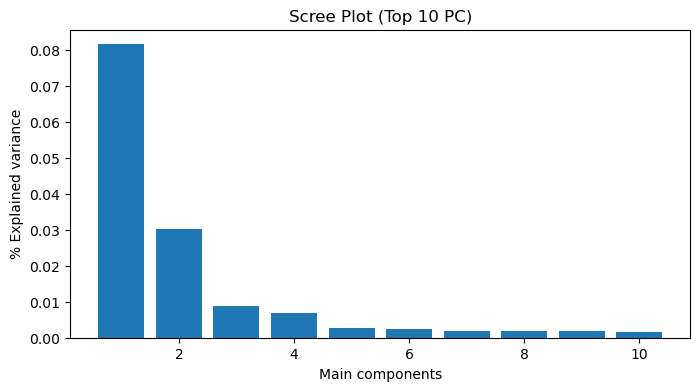

In [31]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# Apply PCA
pca = PCA(n_components= 20)
pca_features = pca.fit_transform(X_scaled)

# Explained variance
plt.figure(figsize=(8, 4))
plt.bar(range(1, 11), pca.explained_variance_ratio_[:10])
plt.xlabel('Main components')
plt.ylabel('% Explained variance')
plt.title('Scree Plot (Top 10 PC)')
plt.show()

            PC1        PC2   sample Population Superpopulation  \
3192  66.969115  -0.486792  NA19203        YRI             AFR   
190   71.625507   3.809698  HG03265        ESN             AFR   
1030  64.997843   2.784077  HG03048        GWD             AFR   
3130 -26.694932 -14.967162  NA21124        GIH             SAS   
550   70.385346   4.251324  HG03370        ESN             AFR   

      coding_one_allele_non_ref  coding_two_alleles_non_ref  \
3192                      172.0                       148.0   
190                       184.0                       146.0   
1030                      171.0                       151.0   
3130                      181.0                       121.0   
550                       178.0                       145.0   

      wg_one_allele_non_ref  wg_two_alleles_non_ref  
3192               205661.0                196714.0  
190                204257.0                195997.0  
1030               204562.0                195614.0  
3130    

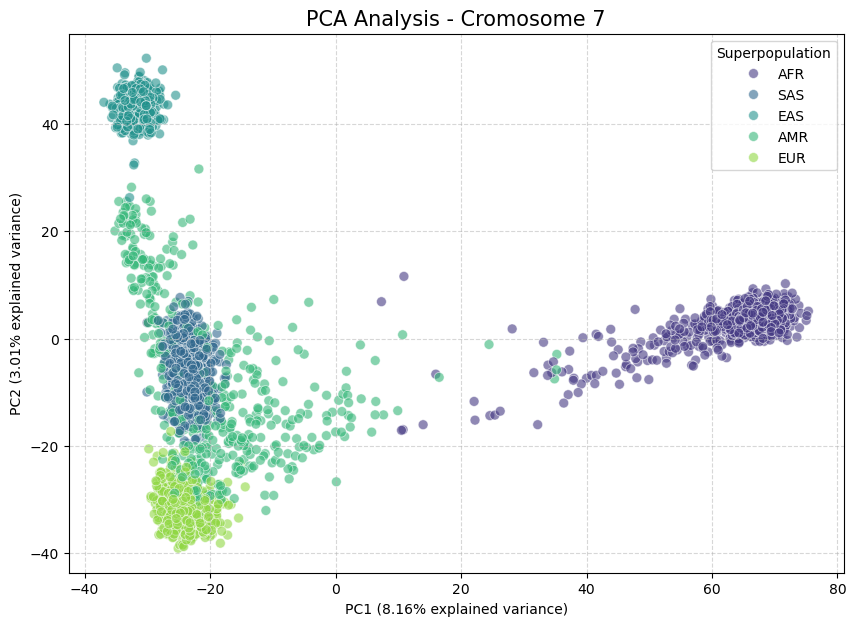

In [46]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Array into data frame 
pca_df = pd.DataFrame(
    data = pca_features[:, :2], # only PC1 and PC2
    columns = ['PC1', 'PC2'],
    index = sample_ids
)

# 2. Load metadata
df_labels = pd.read_csv('sample_type.csv')

# 3. Merge 
pca_merged = pd.merge(
    pca_df, 
    df_labels, 
    left_index=True,      
    right_on='sample'   
)

print(pca_merged.head())

# 4. Graph
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', data=pca_merged, alpha=0.6, hue='Superpopulation', palette='viridis', s=50)
plt.title('PCA Analysis - Cromosome 7', fontsize=15)
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.2%} explained variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.2%} explained variance)')
plt.grid(True, linestyle='--', alpha=0.5)


plt.show()

Clustering analysis

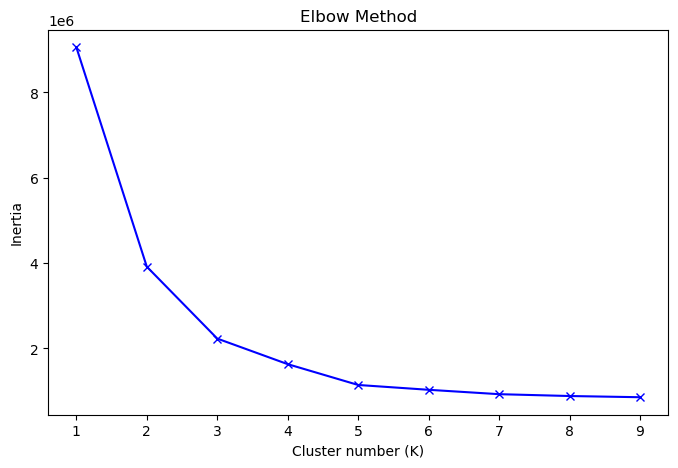

In [48]:
from sklearn.cluster import KMeans

inertia = []
K_range = range(1, 10) # Proviamo da 1 a 9 cluster

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(pca_features[:, :10]) 
    inertia.append(kmeans.inertia_)

# Plot 
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia, 'bx-')
plt.xlabel('Cluster number (K)')
plt.ylabel('Inertia')
plt.title('Elbow Method')
plt.show()

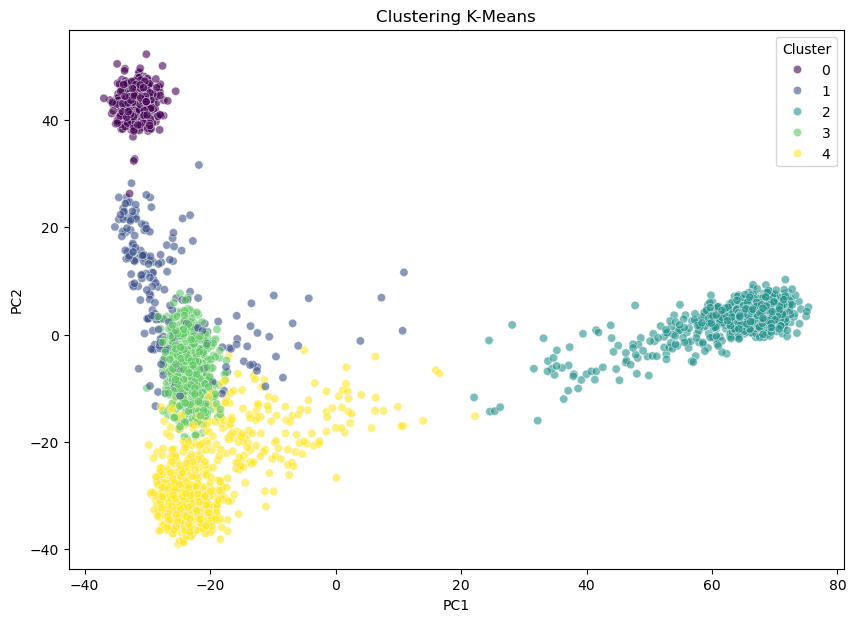

Cluster            0    1    2    3    4
Superpopulation                         
AFR                0    3  885    0    5
AMR                0  217    4    0  269
EAS              585    0    0    0    0
EUR                0    0    0    0  633
SAS                0    0    0  601    0


In [57]:
# Apply KMeans with K = 5 from the graph 
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
clusters = kmeans.fit_predict(pca_features[:, :10])

# Add clusters to data frame
pca_merged['Cluster'] = clusters

# Graph colored per cluster
plt.figure(figsize=(10, 7))
sns.scatterplot(x='PC1', y='PC2', hue='Cluster', data=pca_merged, palette='viridis', alpha=0.6)
plt.title('Clustering K-Means')
plt.show()

# Contingency table
comparison = pd.crosstab(pca_merged['Superpopulation'], pca_merged['Cluster'])
print(comparison)

Supervised classification

In [65]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

# 1. data
X_class = pca_features[:, :10] 
y_class = pca_merged['Superpopulation']

# 2. Split: 80% training, 20% test
X_train, X_test, y_train, y_test = train_test_split(X_class, y_class, test_size=0.2, random_state=42)

# 3. Train
clf = RandomForestClassifier(n_estimators=100, random_state=42)
clf.fit(X_train, y_train)

# 4. Prediction and evaluation
y_pred = clf.predict(X_test)

print("--- CONFUSION MATRIX ---")
print(confusion_matrix(y_test, y_pred))
print("\n--- CLASSIFICATION REPORT ---")
print(classification_report(y_test, y_pred))

--- CONFUSION MATRIX ---
[[185   1   0   0   1]
 [  1  89   0   6   0]
 [  0   0 101   0   0]
 [  0   0   0 134   0]
 [  0   0   0   0 123]]

--- CLASSIFICATION REPORT ---
              precision    recall  f1-score   support

         AFR       0.99      0.99      0.99       187
         AMR       0.99      0.93      0.96        96
         EAS       1.00      1.00      1.00       101
         EUR       0.96      1.00      0.98       134
         SAS       0.99      1.00      1.00       123

    accuracy                           0.99       641
   macro avg       0.99      0.98      0.98       641
weighted avg       0.99      0.99      0.99       641



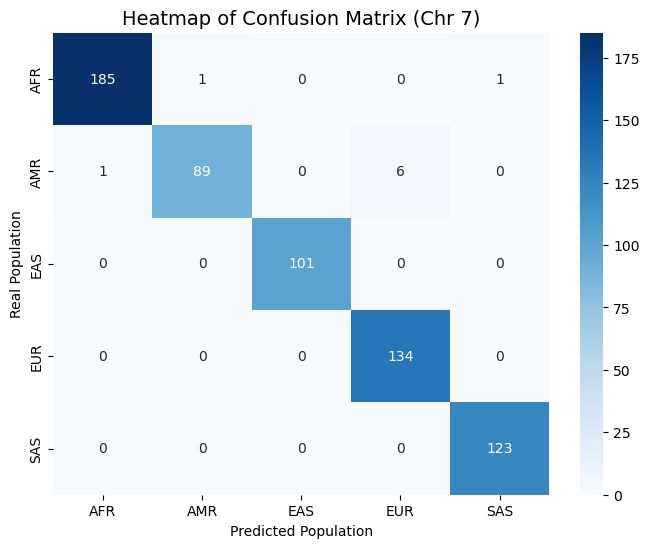

In [66]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
classes = sorted(y_test.unique())

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)

plt.title('Heatmap of Confusion Matrix (Chr 7)', fontsize=14)
plt.ylabel('Real Population')
plt.xlabel('Predicted Population')
plt.show()

/var/folders/vl/x2q7rf7d3hb0vjk4dcdf28p40000gn/T/ipykernel_34603/508871760.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')


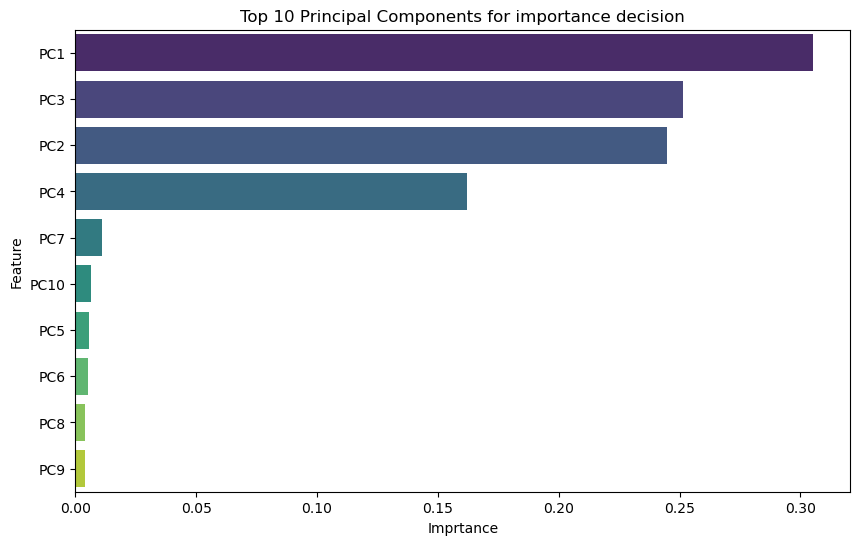

In [67]:
# Importance extraction from the classification
importances = clf.feature_importances_
feature_names = [f'PC{i+1}' for i in range(X_class.shape[1])]

# Data frame
feature_importance_df = pd.DataFrame({'Feature': feature_names, 'Importance': importances})
feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False).head(10)

# Plot
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
plt.title('Top 10 Principal Components for importance decision')
plt.xlabel('Imprtance')
plt.show()

Comparing the PCA analysis from chromosome 22 based on SNPs and the PCA for chromosome 7 based on STRs the results appear quite similar. The population clusters were recognized in both variants and the disposition of the points in the graph is similar, confirming the general global structure, with the popolations EUR, SAS and AMR more overlapping. 

SNPs are less variable, therefore via the ADMIXTURE analysis one can see the proportion of SNPs correlated to each population and allow to see the ancient composition of the populations. In this case from the results it seems that K=3 or K=4 are the best divisions for the groups, wheras if we increase K there is more noise, but no apparently new population is identified, on the other hand if we go lower than K = 3 informaiton is missing. 

STRs are more variable and therefore they can be useful for recent events. STRs are good to identify single individuals, and can be used to train a model to then know to which population the sample belongs to. Via clustering technique it was possible to reach a good division of the population, with almost no mistakes, with the AMR population being the most problematic to classify, which is consistent with the findings based on the PCA results, being that AMR is the most spread population in the graph. 
With supervised clustering the results were very good, with 96 to 100% precision. This proves that one can train a model to recognize the population of an individum based on their STRs. 
In the importance graph for the PC1-10,  one can see that the first 4 are the most important to perform the classification. But what I think is interesting is that PC3 is more important than PC2. This seem to correlate with the ADMIXTURE analysis that showed the best division with K = 3 or 4. It seems that the main structure of the population DNA is covered in the first 4 groups. 

In general STRs anaylsis was much easier, whereas the SNPs analysis was more tedeaus and more time-consuming for the amount of entries (993881 varients, filtered to 8530) and different algorithms compared to the STRs variants (3202 variants). 

